In [1]:
# Notebooks specific imports
from IPython import get_ipython

ipython = get_ipython()
# Expand notebook display

# Display all cell outputs
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"
# autoreload extension
if "autoreload" not in ipython.extension_manager.loaded:
    %load_ext autoreload
%autoreload 2
from tqdm.notebook import tqdm

# Basic useful imports
import re
import time
import yaml
from pprint import pprint
from pathlib import Path
import h5py
from copy import deepcopy

# Data manipulation
import numpy as np
from scipy.special import erf
from scipy.integrate import quad, solve_ivp

from IPython.display import HTML
# Visualization
import matplotlib.animation as animation
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, RegularPolygon, FancyArrowPatch, ArrowStyle
from matplotlib.ticker import (
    MultipleLocator,
    FormatStrFormatter,
    AutoMinorLocator,
    NullFormatter,
)
import matplotlib.colors as colors
from cycler import cycler

from foxlink.graphs import ( me_graph_all_data_2d, draw_rod)

data_dir = 'projects/DATA/n_fil_xlink_tests'



In [2]:
graph_sty = {
    "axes.titlesize": 20,
    "axes.labelsize": 24,
    "lines.linewidth": 2,
    "lines.markersize": 10,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "font.size": 20,
    "font.sans-serif": 'Helvetica',
    "text.usetex": False,
    'mathtext.fontset': 'cm',
}
plt.style.use(graph_sty)

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_18965/1211157758.py:11: SyntaxWarning: invalid escape sequence '\m'
  axarr.set_ylabel('$\mu_{ij}^{00}$')


True

(3, 4, 101)
(3, 4, 101)
(3, 4, 101)
(3, 4, 101)
(3, 4, 101)
(3, 4, 101)
(3, 4, 101)
(3, 4, 101)


Text(0, 0.5, '$\\mu_{ij}^{00}$')

Text(0.5, 0, 'time $t$ [$s$]')

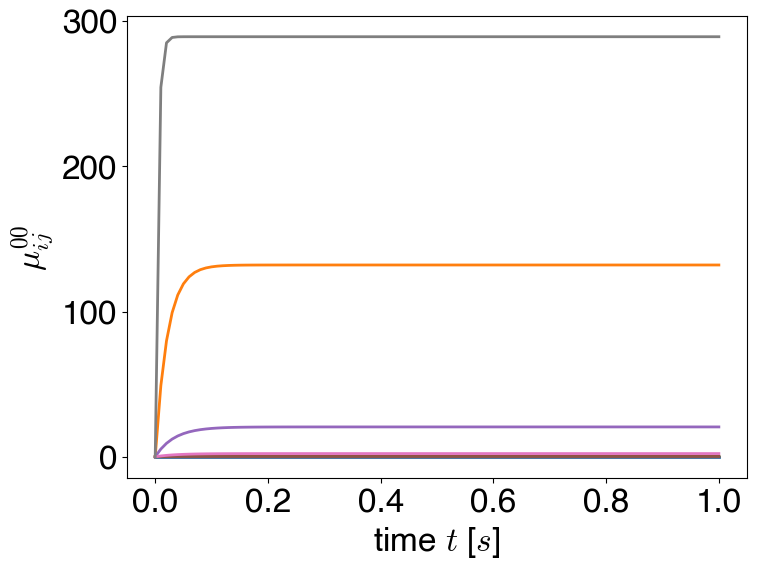

In [ ]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/overlap_3_rods_ke_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,1, figsize=(8, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        print(h5_data['xl_data/moments'].shape)
        time_arr = h5_data['time'][...]
        _ = axarr.plot(time_arr, h5_data['xl_data/moments'][0,0,:])

axarr.set_ylabel('$\mu_{ij}^{00}$')
axarr.set_xlabel('time $t$ [$s$]')  


<>:10: SyntaxWarning: invalid escape sequence '\;'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\;'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_18965/3843184091.py:10: SyntaxWarning: invalid escape sequence '\;'
  _ = axarr.plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'$ko={params["ko"]:.3g}\; s^{{-1}}$')
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_18965/3843184091.py:13: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr.set_ylabel('$\mu_{ij}^{00}$')


True

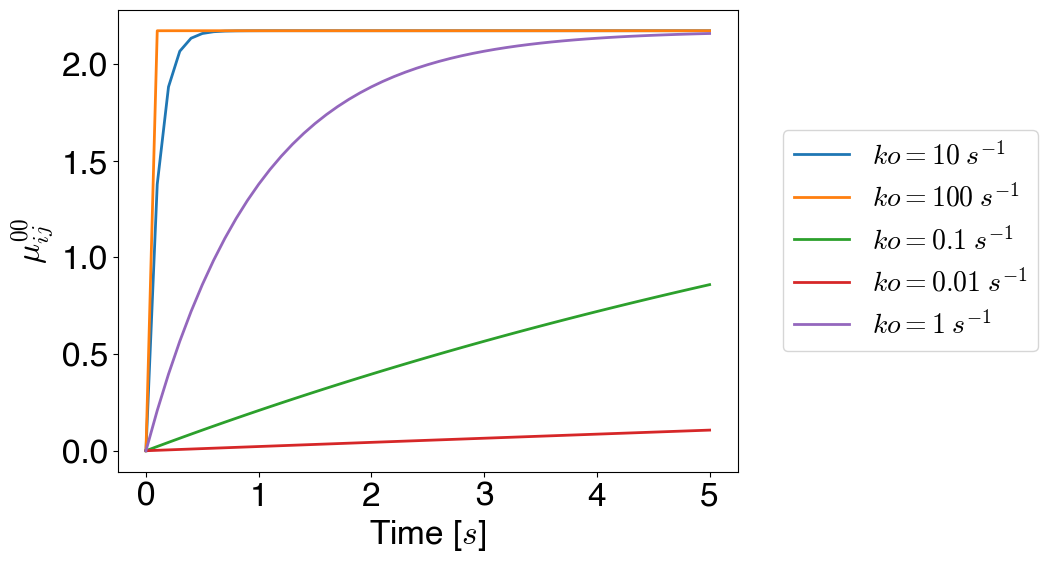

In [5]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/overlap_3_rods_ko_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,1, figsize=(8, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        params = yaml.safe_load(h5_data.attrs['params'])
        # print(h5_data['xl_data/moments'].shape)
        time_arr = h5_data['time'][...]
        _ = axarr.plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'$ko={params["ko"]:.3g}\; s^{{-1}}$')

_ = axarr.legend(loc='center left', bbox_to_anchor=(1.05, .5))
_ = axarr.set_ylabel('$\mu_{ij}^{00}$')
_ = axarr.set_xlabel('Time [$s$]')


<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_18965/2138046476.py:17: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])


True

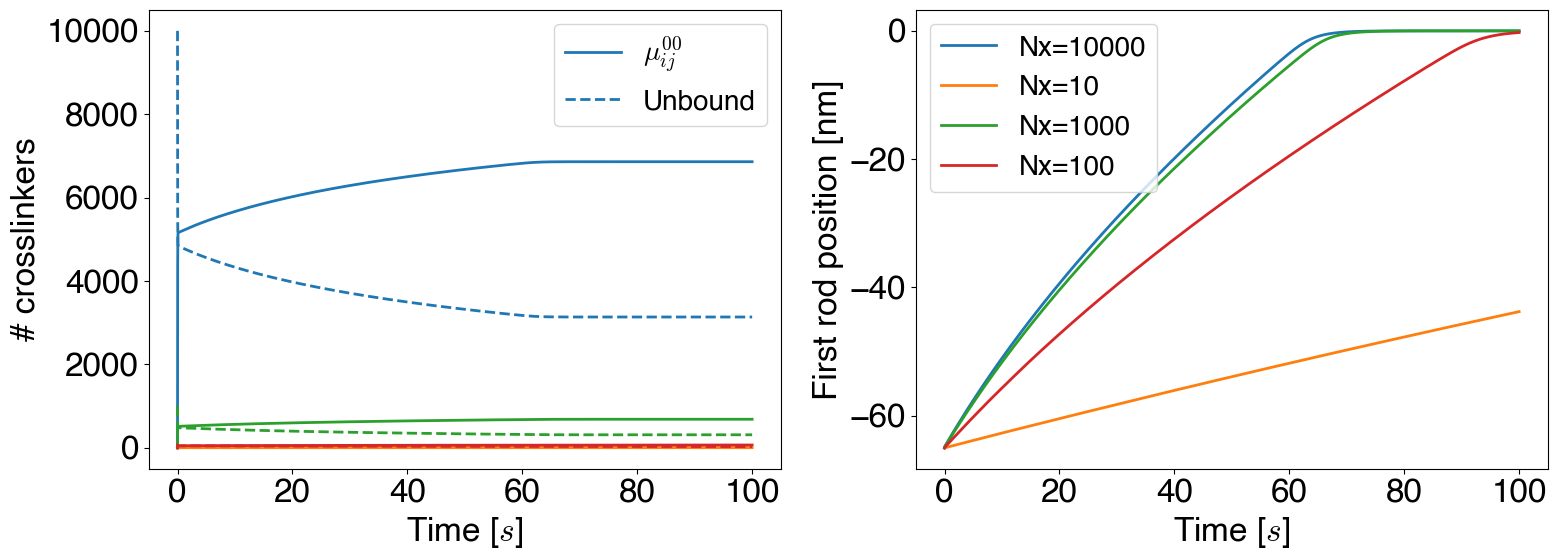

In [6]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_2_rods_Nx_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        # print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'Nx={params["n_unbound"]}')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[1].plot(time_arr, h5_data['rod_data/rod_pos'][0,0,:], label=f'Nx={params["n_unbound"]}')

_ = axarr[0].set_ylabel('# crosslinkers')
_ = axarr[1].set_ylabel('First rod position [nm]')
# _ = axarr[0].set_label(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[1].legend()

for ax in axarr:
    _ = ax.set_xlabel('Time [$s$]')
fig.tight_layout()

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_18965/1285863988.py:19: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])


True

/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_18965/1285863988.py:24: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/Users/alamson/local/miniconda/envs/foxlink/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/alamson/local/miniconda/envs/foxlink/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


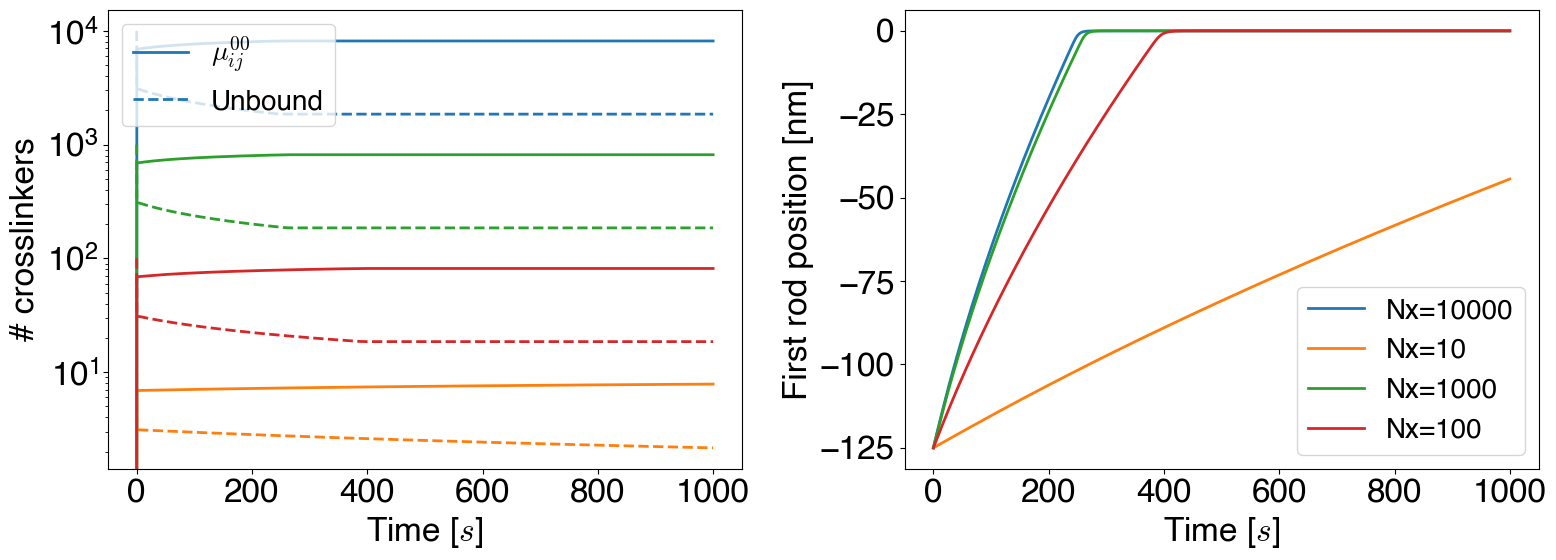

In [12]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_2_long_rods_Nx_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        # print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'Nx={params["n_unbound"]}')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[1].plot(time_arr, h5_data['rod_data/rod_pos'][0,0,:], label=f'Nx={params["n_unbound"]}')

_ = axarr[0].set_ylabel('# crosslinkers')
_ = axarr[0].set_yscale('log')

_ = axarr[1].set_ylabel('First rod position [nm]')
# _ = axarr[0].set_label(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[1].legend()

for ax in axarr:
    _ = ax.set_xlabel('Time [$s$]')
fig.tight_layout()

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_18965/2916438390.py:17: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])


True

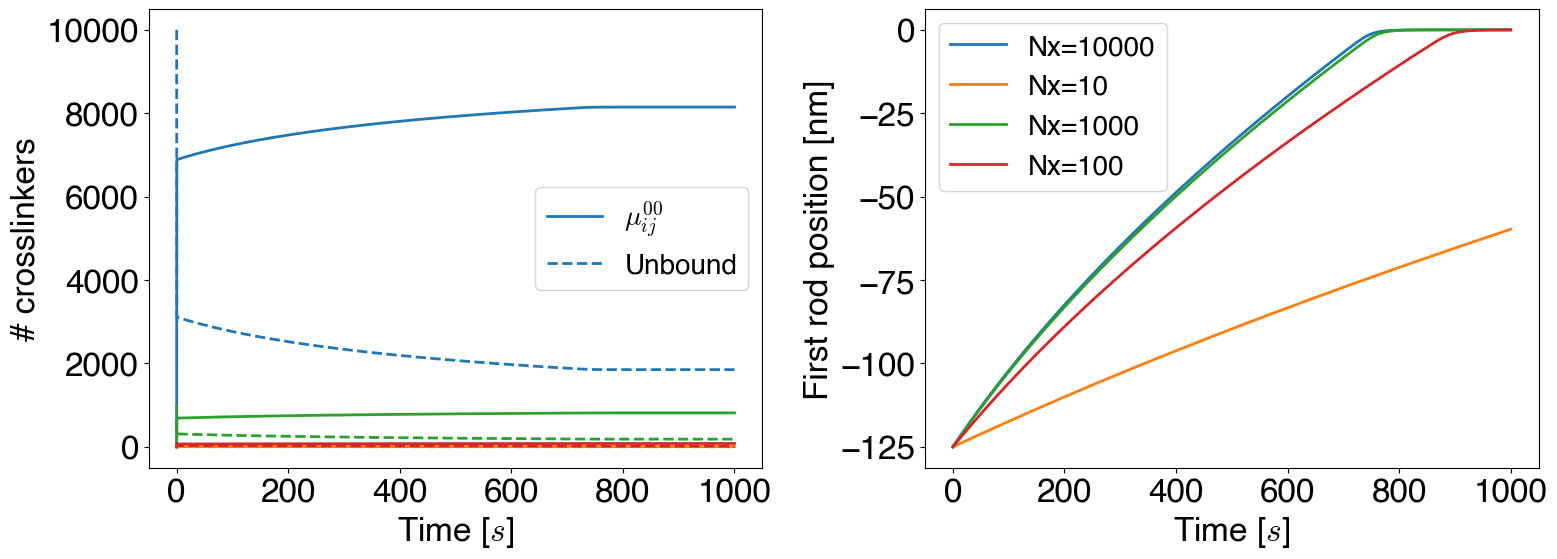

In [10]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_2_long_rods_lowko_Nx_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        # print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'Nx={params["n_unbound"]}')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[1].plot(time_arr, h5_data['rod_data/rod_pos'][0,0,:], label=f'Nx={params["n_unbound"]}')

_ = axarr[0].set_ylabel('# crosslinkers')
_ = axarr[1].set_ylabel('First rod position [nm]')
# _ = axarr[0].set_label(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[1].legend()

for ax in axarr:
    _ = ax.set_xlabel('Time [$s$]')
fig.tight_layout()

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_66761/2167917975.py:19: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])


True

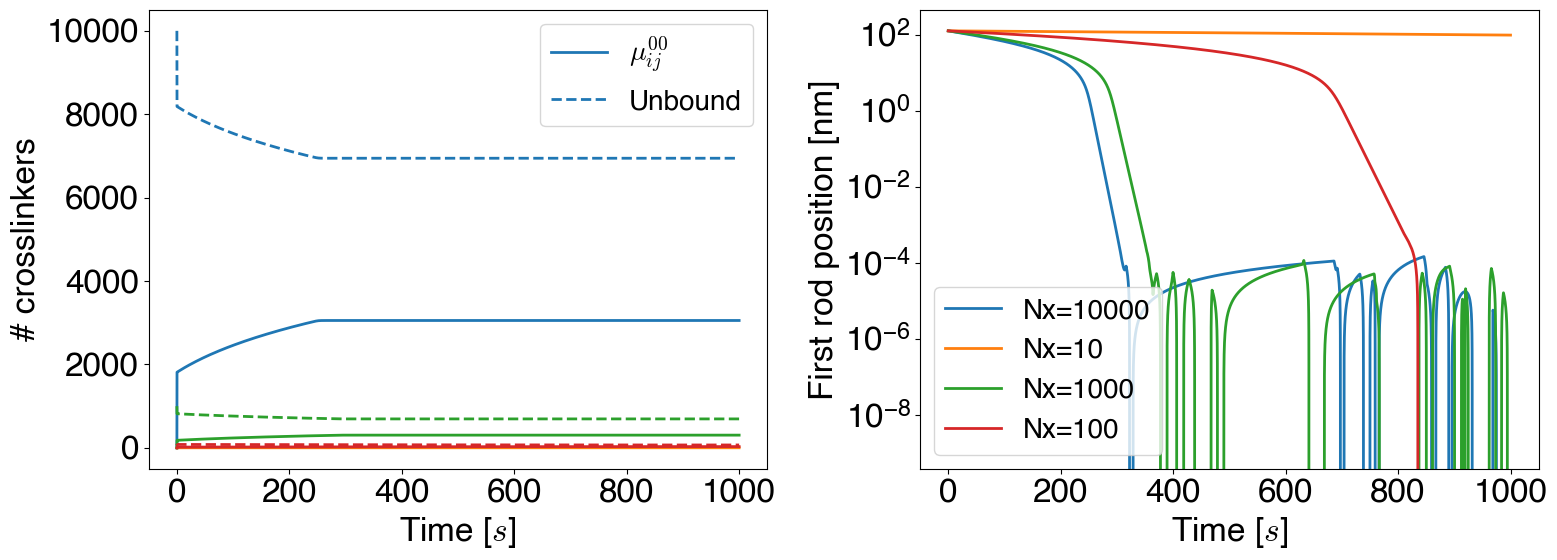

In [10]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_2_long_rods_lowc_Nx_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        # print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'Nx={params["n_unbound"]}')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[1].plot(time_arr, -h5_data['rod_data/rod_pos'][0,0,:], label=f'Nx={params["n_unbound"]}')

_ = axarr[0].set_ylabel('# crosslinkers')
_ = axarr[1].set_ylabel('First rod position [nm]')

# _ = axarr[0].set_label(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[1].legend()

for ax in axarr:
    _ = ax.set_xlabel('Time [$s$]')
fig.tight_layout()

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_18965/1142303963.py:20: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])


True

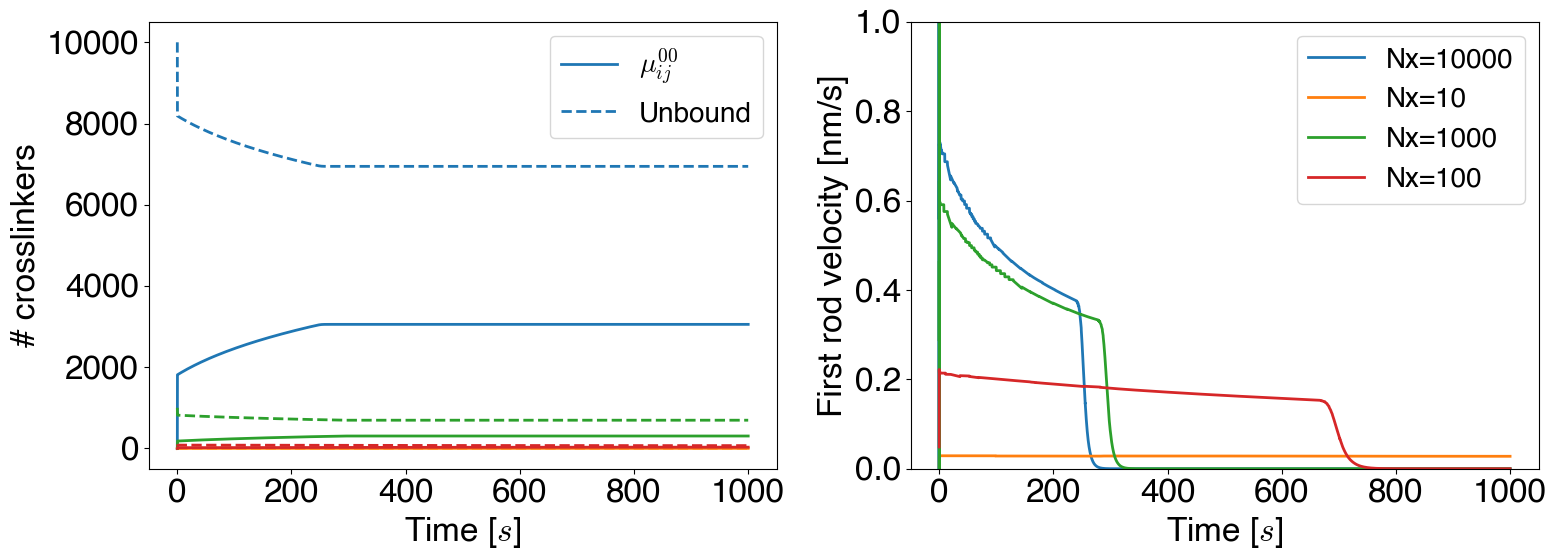

In [22]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_2_long_rods_lowc_Nx_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        # print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'Nx={params["n_unbound"]}')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[1].plot(time_arr[:-1], np.diff(h5_data['rod_data/rod_pos'][0,0,:])/(np.diff(time_arr)[-1]), label=f'Nx={params["n_unbound"]}')

_ = axarr[0].set_ylabel('# crosslinkers')
_ = axarr[1].set_ylabel('First rod velocity [nm/s]')
# _ = axarr[0].set_yscale('log')
# _ = axarr[1].set_yscale('log')
# _ = axarr[0].set_label(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[1].set_ylim(0,1)
_ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[1].legend()

for ax in axarr:
    _ = ax.set_xlabel('Time [$s$]')
fig.tight_layout()

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_79061/2914804964.py:13: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr[0].set_ylabel('$\mu_{ij}^{00}$')


True

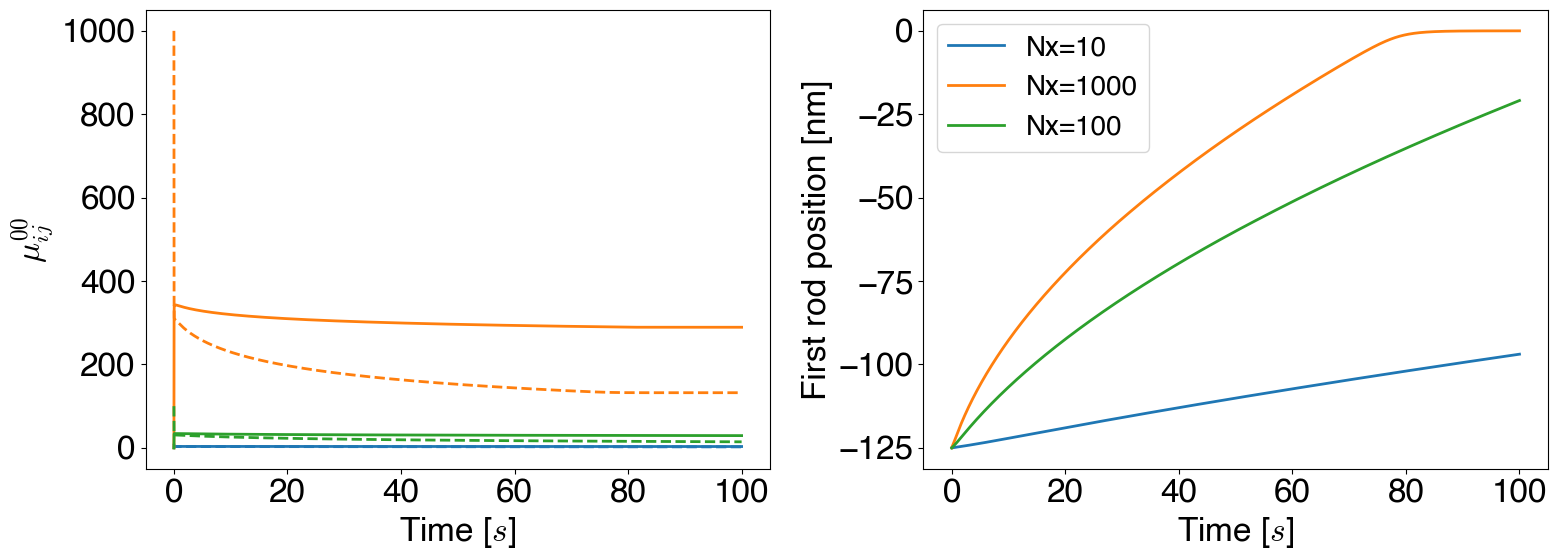

In [21]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_3_rods_Nx_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        # print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'Nx={params["n_unbound"]}')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[1].plot(time_arr, h5_data['rod_data/rod_pos'][0,0,:], label=f'Nx={params["n_unbound"]}')
_ = axarr[0].set_ylabel('$\mu_{ij}^{00}$')
_ = axarr[1].set_ylabel('First rod position [nm]')
_ = axarr[1].legend()

for ax in axarr:
    _ = ax.set_xlabel('Time [$s$]')
fig.tight_layout()

True

(3, 4, 10001)


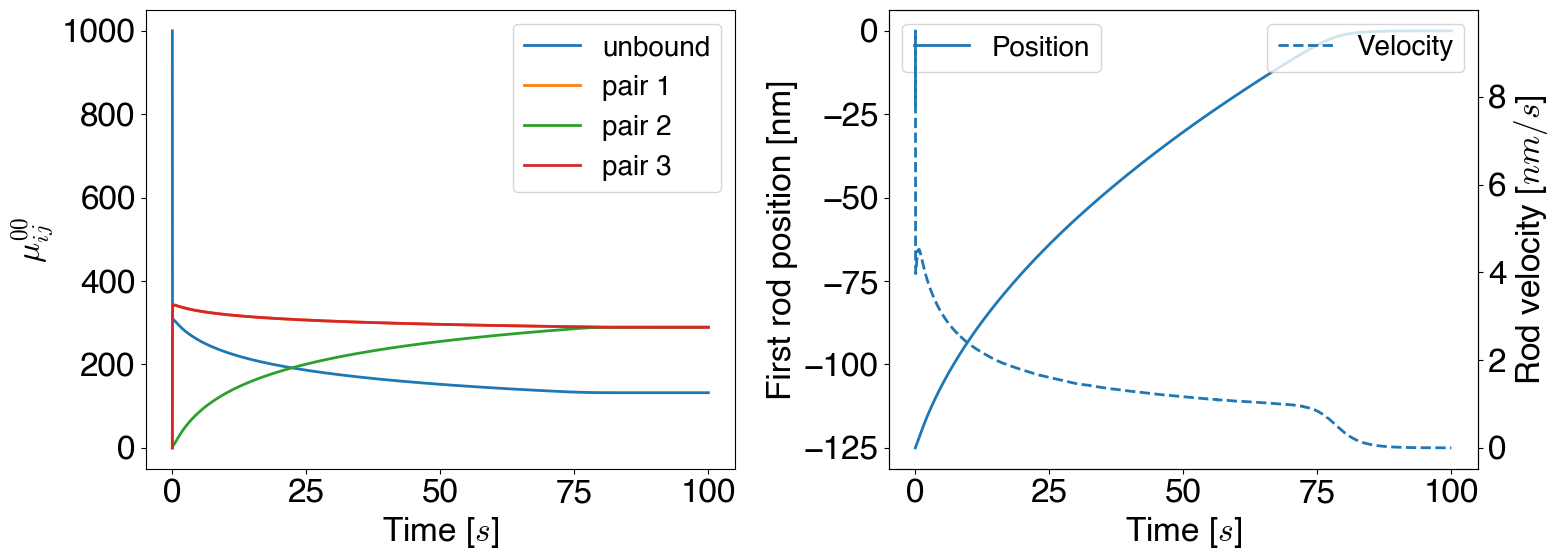

In [31]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_3_rods_Nx_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in list(data_path.glob('**/*.h5'))[1:]:
    with h5py.File(h5_data, 'r') as h5_data:
        print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:],  label=f'unbound')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'pair 1')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][1,0,:], label=f'pair 2')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][2,0,:], label=f'pair 3')
        rod_pos = h5_data['rod_data']['rod_pos'][0,0,:] 
        rod_vel = np.diff(rod_pos)/np.diff(time_arr)[-1]
        _ = axarr[1].plot(time_arr, rod_pos, label=f'Nx={params["n_unbound"]}')
        axshare = axarr[1].twinx()
        _ = axshare.plot(time_arr[:-1], rod_vel, linestyle='--', label=f'Nx={params["n_unbound"]}')

    break
_ = axarr[0].legend()
_ = axarr[0].set_ylabel(r'$\mu_{ij}^{00}$')
_ = axarr[0].set_xlabel('time $t$ [$s$]')
_ = axarr[1].set_ylabel('First rod position [nm]')
_ = axshare.set_ylabel('Rod velocity [$nm/s$]')
_ = axarr[1].legend(['Position'])
_ = axshare.legend([ 'Velocity'])
for ax in axarr:
    _ = ax.set_xlabel('Time [$s$]')
fig.tight_layout()
# _ = axarr[0].set_yscale('log')

True

(1, 4, 10001)


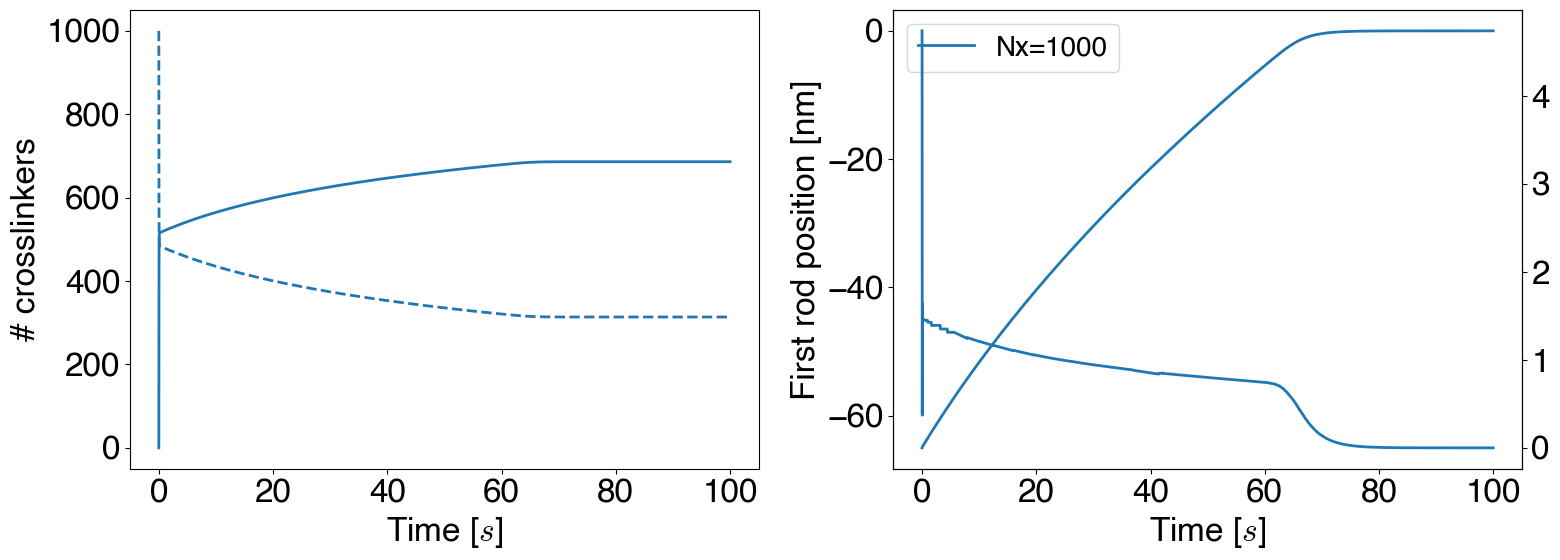

In [9]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_2_rods_Nx_scan/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in list(data_path.glob('**/*.h5'))[2:]:
    with h5py.File(h5_data, 'r') as h5_data:
        print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'pair 1')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        rod_pos = h5_data['rod_data']['rod_pos'][0,0,:] 
        rod_vel = np.diff(rod_pos)/np.diff(time_arr)[-1]
        _ = axarr[1].plot(time_arr, rod_pos, label=f'Nx={params["n_unbound"]}')
        axshare = axarr[1].twinx()
        _ = axshare.plot(time_arr[:-1], rod_vel, label=f'Nx={params["n_unbound"]}')

    break

_ = axarr[0].set_ylabel('# crosslinkers')
_ = axarr[1].set_ylabel('First rod position [nm]')
_ = axarr[1].legend()

for ax in axarr:
    _ = ax.set_xlabel('Time [$s$]')
fig.tight_layout()

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_79061/3712059383.py:16: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])


True

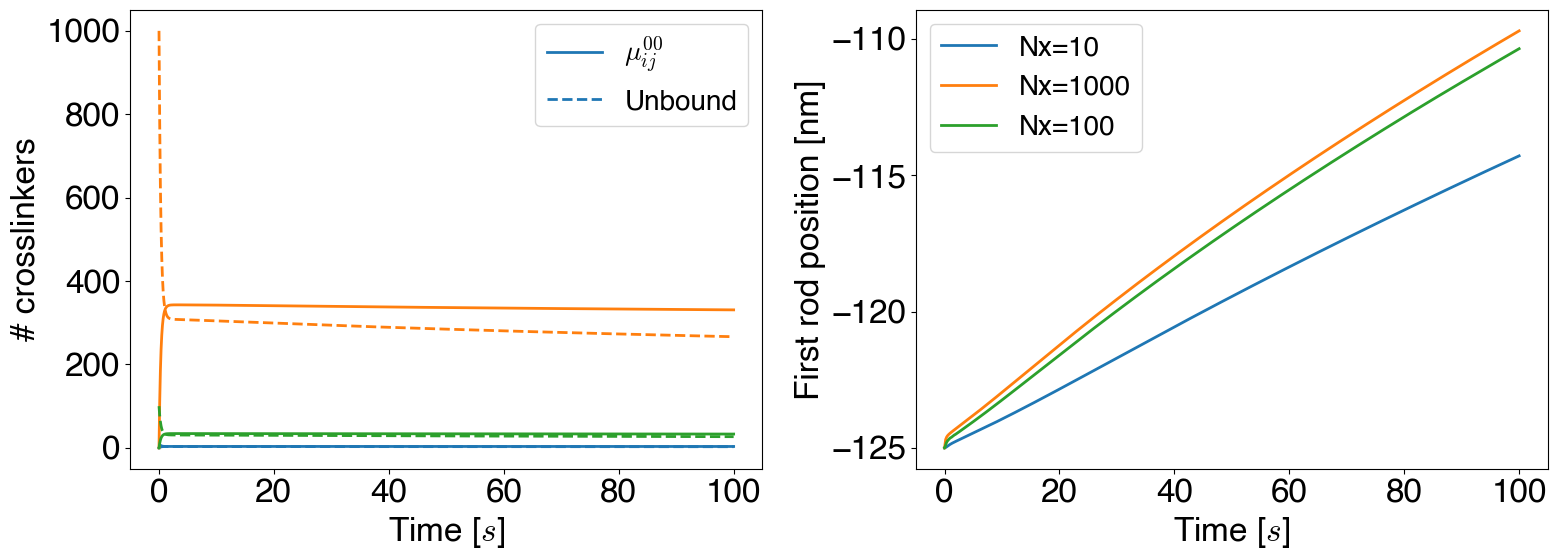

In [38]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_3_rods_Nx_scan_ko1/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in data_path.glob('**/*.h5'):
    with h5py.File(h5_data, 'r') as h5_data:
        # print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'Nx={params["n_unbound"]}')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[1].plot(time_arr, h5_data['rod_data/rod_pos'][0,0,:], label=f'Nx={params["n_unbound"]}')
_ = axarr[0].set_ylabel('# crosslinkers')
_ = axarr[1].set_ylabel('First rod position [nm]')
# _ = axarr[0].set_label(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[1].legend()

for ax in axarr:
    _ = ax.set_xlabel('Time [$s$]')
fig.tight_layout()

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_79061/1256595654.py:24: SyntaxWarning: invalid escape sequence '\m'
  _ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])


True

(3, 4, 10001)


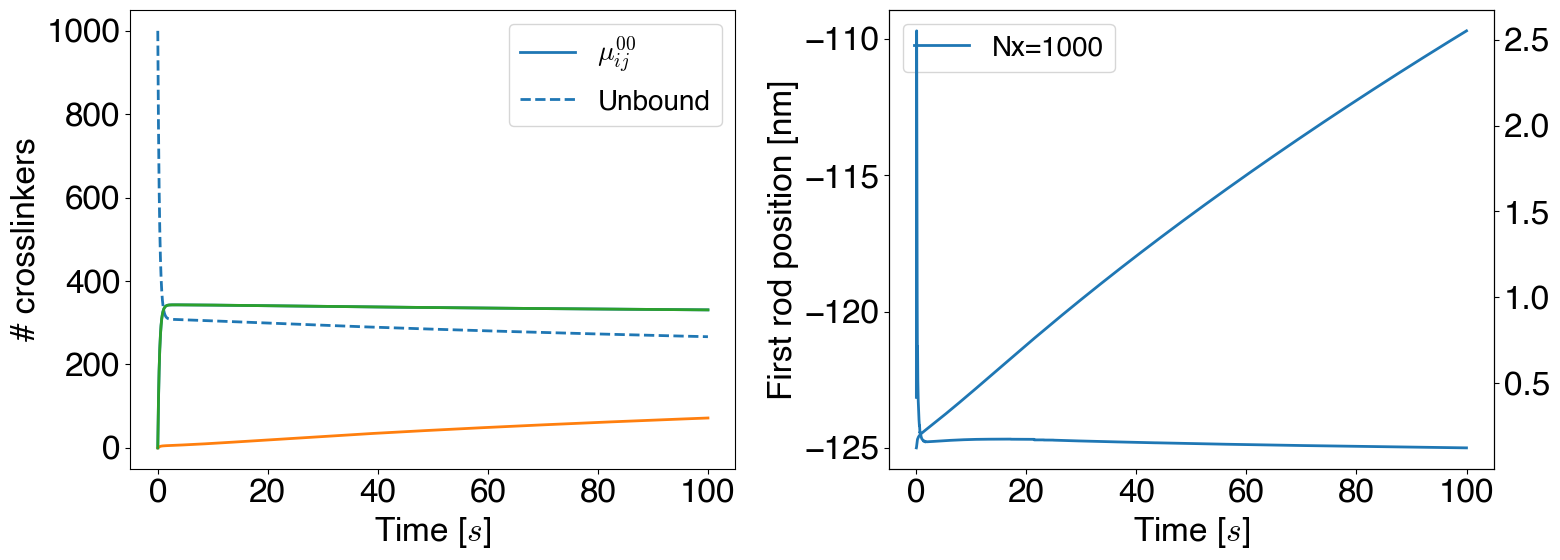

In [41]:
data_path = Path.home() / 'projects/DATA/n_fil_xlink_tests/slide_3_rods_Nx_scan_ko1/'
data_path.exists()
fig, axarr = plt.subplots(1,2, figsize=(16, 6))

for h5_data in list(data_path.glob('**/*.h5'))[1:]:
    with h5py.File(h5_data, 'r') as h5_data:
        print(h5_data['xl_data/moments'].shape)
        params = yaml.safe_load(h5_data.attrs['params'])
        time_arr = h5_data['time'][...]
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][0,0,:], label=f'pair 1')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/unbound'][:], linestyle='--', color=_[-1].get_color())
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][1,0,:], label=f'pair 2')
        _ = axarr[0].plot(time_arr, h5_data['xl_data/moments'][2,0,:], label=f'pair 3')
        rod_pos = h5_data['rod_data']['rod_pos'][0,0,:] 
        rod_vel = np.diff(rod_pos)/np.diff(time_arr)[-1]
        _ = axarr[1].plot(time_arr, rod_pos, label=f'Nx={params["n_unbound"]}')
        axshare = axarr[1].twinx()
        _ = axshare.plot(time_arr[:-1], rod_vel, label=f'Nx={params["n_unbound"]}')

    break
_ = axarr[0].set_ylabel('# crosslinkers')
_ = axarr[1].set_ylabel('First rod position [nm]')
# _ = axarr[0].set_label(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[0].legend(['$\mu_{ij}^{00}$', 'Unbound'])
_ = axarr[1].legend()

for ax in axarr:
    _ = ax.set_xlabel('Time [$s$]')
fig.tight_layout()

In [42]:
import pyvista
from pyvista import examples


In [43]:
hexbeam = examples.load_hexbeam()

In [46]:
hexbeam

/Users/alamson/local/miniconda/envs/foxlink/lib/python3.12/site-packages/vtkmodules/util/numpy_support.py:74: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  _vtk_np = {vtkConstants.VTK_BIT:numpy.bool,


AttributeError: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the builtin `bool`. To avoid this error in existing code, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

UnstructuredGrid (0x1252f5960)
  N Cells:    40
  N Points:   99
  X Bounds:   0.000e+00, 1.000e+00
  Y Bounds:   0.000e+00, 1.000e+00
  Z Bounds:   0.000e+00, 5.000e+00
  N Arrays:   3